# 03 — Model architecture and Light-S validation

This notebook starts the **model stage** of the Efficient Saliency Prediction project.

We do **not** launch a full training run immediately. First we establish a reliable architecture contract:

- the encoder returns the expected multi-resolution features;
- the decoder returns one raw saliency-logit map;
- output and target shapes match exactly;
- spatial softmax produces a valid probability distribution;
- the loss is finite;
- gradients reach both encoder and decoder;
- Light-S can begin to overfit one tiny batch.

Only after these checks pass should the shared training code be implemented in `src/train_eval.py`.

## 1. Where this stage sits in the complete project

```text
SALICON files
     │
     ▼
src/data.py ───────────────► image [B, 3, H, W]
                             target [B, 1, H, W], sum = 1
                                      │
                                      ▼
                              src/models.py
                         encoder ─► decoder
                                      │
                                      ▼
                              logits [B, 1, H, W]
                                      │
                                      ▼
                         spatial softmax + loss
                       src/losses_metrics.py
                                      │
                                      ▼
                            backward + optimizer
                                      │
                                      ▼
                          src/train_eval.py (next)
```

The important separation is:

- `data.py` decides **what enters the model**;
- `models.py` decides **how the prediction is produced**;
- `losses_metrics.py` decides **how prediction quality is measured**;
- `train_eval.py` will decide **how training and validation are executed**.

## 2. The controlled model comparison

```text
Light-S
RGB ─► MobileNetV2 ─► F32 ─► compact decoder ─► logits
                         deepest semantic information only

Light-M
RGB ─► MobileNetV2 ─► F4, F8, F16, F32 ─► skip fusion ─► logits
                         local detail + global semantics

Heavy-M
RGB ─► ResNet-18 ───► F4, F8, F16, F32 ─► same decoder ─► logits
                         larger encoder-capacity reference
```

This gives two clean comparisons:

1. `Light-S` vs `Light-M` isolates the value of **multi-scale fusion**.
2. `Light-M` vs `Heavy-M` isolates the value of **encoder capacity**.

We begin with `Light-S` because it is the simplest learned baseline and therefore the best model for debugging the complete pipeline.

## 3. Colab, Drive, and repository setup

This cell avoids `%autoreload`, which can fail in some recent Colab environments. When `src/models.py` is edited, restart the runtime or use `importlib.reload` explicitly.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import subprocess
import sys

REPO_URL = "https://github.com/RicoDalB/efficient-saliency-prediction.git"
REPO_ROOT = Path("/content/efficient-saliency-prediction")
DRIVE_ROOT = Path("/content/drive/MyDrive/saliency_project")
DATA_ROOT = DRIVE_ROOT / "data" / "SALICON"

if not REPO_ROOT.exists():
    subprocess.run(
        ["git", "clone", REPO_URL, str(REPO_ROOT)],
        check=True,
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

TRAIN_MANIFEST_PATH = REPO_ROOT / "splits" / "train_manifest.csv"

assert REPO_ROOT.is_dir(), f"Repository not found: {REPO_ROOT}"
assert DATA_ROOT.is_dir(), f"SALICON data not found: {DATA_ROOT}"
assert TRAIN_MANIFEST_PATH.is_file(), f"Manifest not found: {TRAIN_MANIFEST_PATH}"

print("Repository:", REPO_ROOT)
print("Dataset:   ", DATA_ROOT)
print("Manifest:  ", TRAIN_MANIFEST_PATH)

Mounted at /content/drive
Repository: /content/efficient-saliency-prediction
Dataset:    /content/drive/MyDrive/saliency_project/data/SALICON
Manifest:   /content/efficient-saliency-prediction/splits/train_manifest.csv


## 4. Imports and reproducibility

The project keeps the fixed seed `42`. The model returns **raw logits**; no sigmoid or softmax belongs inside the architecture.

In [23]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch

from src.data import SaliconDataset, build_dataloader
from src.losses_metrics import (
    saliency_loss,
    spatial_softmax,
    validate_spatial_distribution,
)
from src.models import build_model, parameter_summary

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_SIZE = (169, 256)  # (height, width), matching src/data.py
DECODER_CHANNELS = 32

print("Device:", DEVICE)
print("PyTorch:", torch.__version__)

Device: cuda
PyTorch: 2.11.0+cu128


## 5. Build the Light-S model

`Light-S` contains:

1. an ImageNet-pretrained MobileNetV2 encoder;
2. one projection of the deepest stride-32 feature to 32 channels;
3. three bilinear upsampling + lightweight refinement steps;
4. one `1×1` prediction head;
5. a final resize to the original input resolution.

The decoder never fuses the values of shallow features. Their spatial sizes are used only to make resizing robust for odd image dimensions.

In [24]:
model = build_model(
    "light_single",
    pretrained=True,
    decoder_channels=DECODER_CHANNELS,
).to(DEVICE)

summary = parameter_summary(model)
summary

{'encoder': 1811712, 'decoder': 14401, 'total': 1826113, 'trainable': 1826113}

## 6. Verify the encoder feature contract

For the project input `169×256`, MobileNetV2 should produce approximately:

```text
F4  : [B,  24, 43, 64]   fine spatial detail
F8  : [B,  32, 22, 32]
F16 : [B,  96, 11, 16]
F32 : [B, 320,  6,  8]   deepest semantic information
```

The exact dimensions are checked rather than assumed.

In [25]:
dummy_images = torch.randn(
    1,
    3,
    OUTPUT_SIZE[0],
    OUTPUT_SIZE[1],
    device=DEVICE,
)

model.eval()
with torch.inference_mode():
    feature_maps = model.encoder(dummy_images)

for name, feature_map in feature_maps.items():
    print(f"{name}: {tuple(feature_map.shape)}")

assert set(feature_maps) == {"s4", "s8", "s16", "s32"}

s4: (1, 24, 43, 64)
s8: (1, 32, 22, 32)
s16: (1, 96, 11, 16)
s32: (1, 320, 6, 8)


## 7. Verify the complete forward pass

The architecture must return one raw logit per output pixel. The final shape must be identical to the target shape, including the odd input height of 169 pixels.

In [26]:
with torch.inference_mode():
    dummy_logits = model(dummy_images)

print("Input shape: ", tuple(dummy_images.shape))
print("Output shape:", tuple(dummy_logits.shape))

assert dummy_logits.shape == (1, 1, *OUTPUT_SIZE)
assert torch.isfinite(dummy_logits).all()

print("Forward-pass check passed.")

Input shape:  (1, 3, 169, 256)
Output shape: (1, 1, 169, 256)
Forward-pass check passed.


## 8. Verify the output-distribution contract

The model itself returns logits. `spatial_softmax` converts every `H×W` prediction into one probability distribution whose pixels sum to one.

In [27]:
with torch.inference_mode():
    dummy_prediction = spatial_softmax(dummy_logits)

prediction_mass = dummy_prediction.flatten(start_dim=1).sum(dim=1)
print("Prediction mass:", prediction_mass)

validate_spatial_distribution(dummy_prediction, name="dummy_prediction")
print("Spatial-distribution check passed.")

Prediction mass: tensor([1.0000], device='cuda:0')
Spatial-distribution check passed.


## 9. Build a real SALICON batch

The manifest columns already present in the repository are:

- `sample_id`
- `image_relpath`
- `map_relpath`

For this architecture notebook, `num_workers=0` keeps debugging transparent. Worker tuning belongs to the later training stage.

In [28]:
train_dataset = SaliconDataset(
    manifest_path=TRAIN_MANIFEST_PATH,
    data_root=DATA_ROOT,
    image_column="image_relpath",
    map_column="map_relpath",
    id_column="sample_id",
    output_size=OUTPUT_SIZE,
    use_imagenet_normalization=True,
)

train_loader = build_dataloader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    seed=SEED,
    num_workers=0,
)

batch = next(iter(train_loader))
images = batch["image"].to(DEVICE)
targets = batch["target"].to(DEVICE)

print("Image batch: ", tuple(images.shape))
print("Target batch:", tuple(targets.shape))
print("Sample IDs:  ", batch["sample_id"])
print("Target mass: ", targets.flatten(start_dim=1).sum(dim=1))

assert images.shape == (4, 3, *OUTPUT_SIZE)
assert targets.shape == (4, 1, *OUTPUT_SIZE)
validate_spatial_distribution(targets, name="targets")

Image batch:  (4, 3, 169, 256)
Target batch: (4, 1, 169, 256)
Sample IDs:   ['460915', '372003', '564681', '220234']
Target mass:  tensor([1.0000, 1.0000, 1.0000, 1.0000], device='cuda:0')


## 10. Connect model and loss

This is the first complete path through the project:

```text
real images ─► Light-S ─► logits ─► saliency_loss(logits, targets)
```

A finite loss confirms that `data.py`, `models.py`, and `losses_metrics.py` agree on shapes and normalization.

In [29]:
model.train()
logits = model(images)
loss = saliency_loss(logits, targets)

print("Logit shape:", tuple(logits.shape))
print("Loss:", float(loss.detach()))

assert logits.shape == targets.shape
assert torch.isfinite(loss)

print("Model-loss integration check passed.")

Logit shape: (4, 1, 169, 256)
Loss: 1.7837347984313965
Model-loss integration check passed.


## 11. Verify gradient flow

A valid forward pass is not enough. The loss must generate gradients in both the pretrained encoder and the new decoder.

In [30]:
model.zero_grad(set_to_none=True)
loss.backward()

encoder_has_gradient = any(
    parameter.grad is not None
    for parameter in model.encoder.parameters()
    if parameter.requires_grad
)
decoder_has_gradient = any(
    parameter.grad is not None
    for parameter in model.decoder.parameters()
    if parameter.requires_grad
)

print("Encoder receives gradients:", encoder_has_gradient)
print("Decoder receives gradients:", decoder_has_gradient)

assert encoder_has_gradient
assert decoder_has_gradient

print("Backward-pass check passed.")

Encoder receives gradients: True
Decoder receives gradients: True
Backward-pass check passed.


## 12. Visualize one untrained prediction

The prediction is not expected to be meaningful yet. This panel checks only that:

- the RGB image is reconstructed correctly after ImageNet denormalization;
- the target is spatially aligned;
- the prediction has the expected orientation and dimensions.

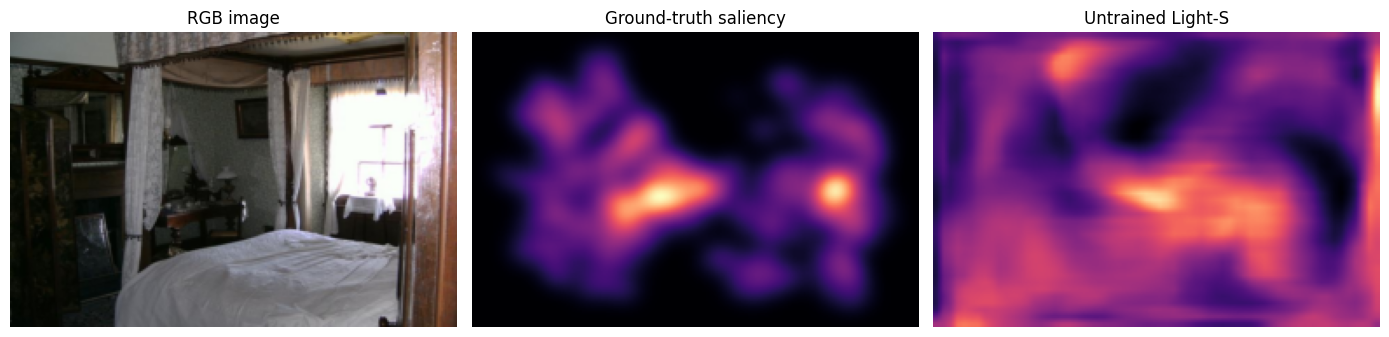

In [31]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

model.eval()
with torch.inference_mode():
    prediction = spatial_softmax(model(images[:1])).cpu()[0, 0]

image_to_show = images[0].detach().cpu() * IMAGENET_STD + IMAGENET_MEAN
image_to_show = image_to_show.clamp(0, 1).permute(1, 2, 0)
target_to_show = targets[0, 0].detach().cpu()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(image_to_show)
axes[0].set_title("RGB image")
axes[1].imshow(target_to_show, cmap="magma")
axes[1].set_title("Ground-truth saliency")
axes[2].imshow(prediction, cmap="magma")
axes[2].set_title("Untrained Light-S")

for axis in axes:
    axis.axis("off")

plt.tight_layout()
plt.show()

## 13. Tiny-batch overfitting gate

This is a diagnostic experiment, not the final training procedure.

We repeatedly optimize the same four samples. A healthy model should reduce the loss and begin adapting its map to those samples. Failure usually indicates a problem with gradients, normalization, learning rate, or the tensor contract.

Run only after every previous check passes.

step 01/40 - loss: 1.4924
step 10/40 - loss: 0.3764
step 20/40 - loss: 0.2515
step 30/40 - loss: 0.1540
step 40/40 - loss: 0.0946


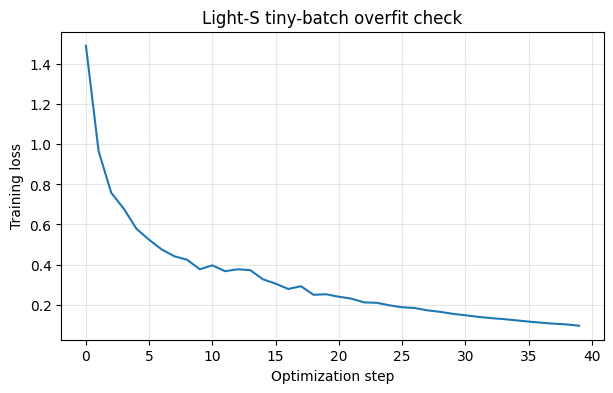

Initial loss: 1.4924306869506836
Final loss:   0.09457704424858093


In [32]:
tiny_model = build_model(
    "light_single",
    pretrained=True,
    decoder_channels=DECODER_CHANNELS,
).to(DEVICE)

tiny_optimizer = torch.optim.AdamW(
    tiny_model.parameters(),
    lr=1e-3,
    weight_decay=0.0,
)

tiny_losses = []
TINY_STEPS = 40

tiny_model.train()
for step in range(TINY_STEPS):
    tiny_optimizer.zero_grad(set_to_none=True)

    tiny_logits = tiny_model(images)
    tiny_loss = saliency_loss(tiny_logits, targets)
    tiny_loss.backward()
    tiny_optimizer.step()

    tiny_losses.append(float(tiny_loss.detach()))

    if step == 0 or (step + 1) % 10 == 0:
        print(f"step {step + 1:02d}/{TINY_STEPS} - loss: {tiny_losses[-1]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(tiny_losses)
plt.xlabel("Optimization step")
plt.ylabel("Training loss")
plt.title("Light-S tiny-batch overfit check")
plt.grid(alpha=0.3)
plt.show()

print("Initial loss:", tiny_losses[0])
print("Final loss:  ", tiny_losses[-1])

## 14. Confirm that all three project models share the same interface

We are not training `Light-M` or `Heavy-M` here. This cell only confirms that the shared factory creates all planned architectures and reports their parameter counts.

In [33]:
model_names = ["light_single", "light_multi", "heavy_multi"]

for model_name in model_names:
    candidate = build_model(
        model_name,
        pretrained=False,
        decoder_channels=DECODER_CHANNELS,
    )
    counts = parameter_summary(candidate)
    print(
        f"{model_name:13s} | "
        f"encoder={counts['encoder']:,} | "
        f"decoder={counts['decoder']:,} | "
        f"total={counts['total']:,}"
    )
    del candidate

light_single  | encoder=1,811,712 | decoder=14,401 | total=1,826,113
light_multi   | encoder=1,811,712 | decoder=19,265 | total=1,830,977
heavy_multi   | encoder=11,176,512 | decoder=34,881 | total=11,211,393


## 15. Definition of done for this notebook

Before moving to shared training code, all boxes must be checked:

```text
[ ] MobileNetV2 returns s4, s8, s16, and s32 features
[ ] Light-S output has shape [B, 1, 169, 256]
[ ] spatial softmax sums to one for every sample
[ ] real SALICON targets pass distribution validation
[ ] saliency loss is finite
[ ] gradients reach encoder and decoder
[ ] tiny-batch loss decreases
[ ] visualized image and target remain aligned
[ ] all three planned model names can be constructed
```

### Next implementation stage

Create `src/train_eval.py` with one shared training/validation loop, checkpoint saving, epoch metrics, and CSV history. Then use this notebook to run the final Light-S experiment before moving to `04_light_multi.ipynb`.